In [4]:
import os
import sys
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt

# Tambahkan path backend
sys.path.append(".")
from train_mlflow import LAG, series_to_supervised
from preprocessing import bersihkan_harga

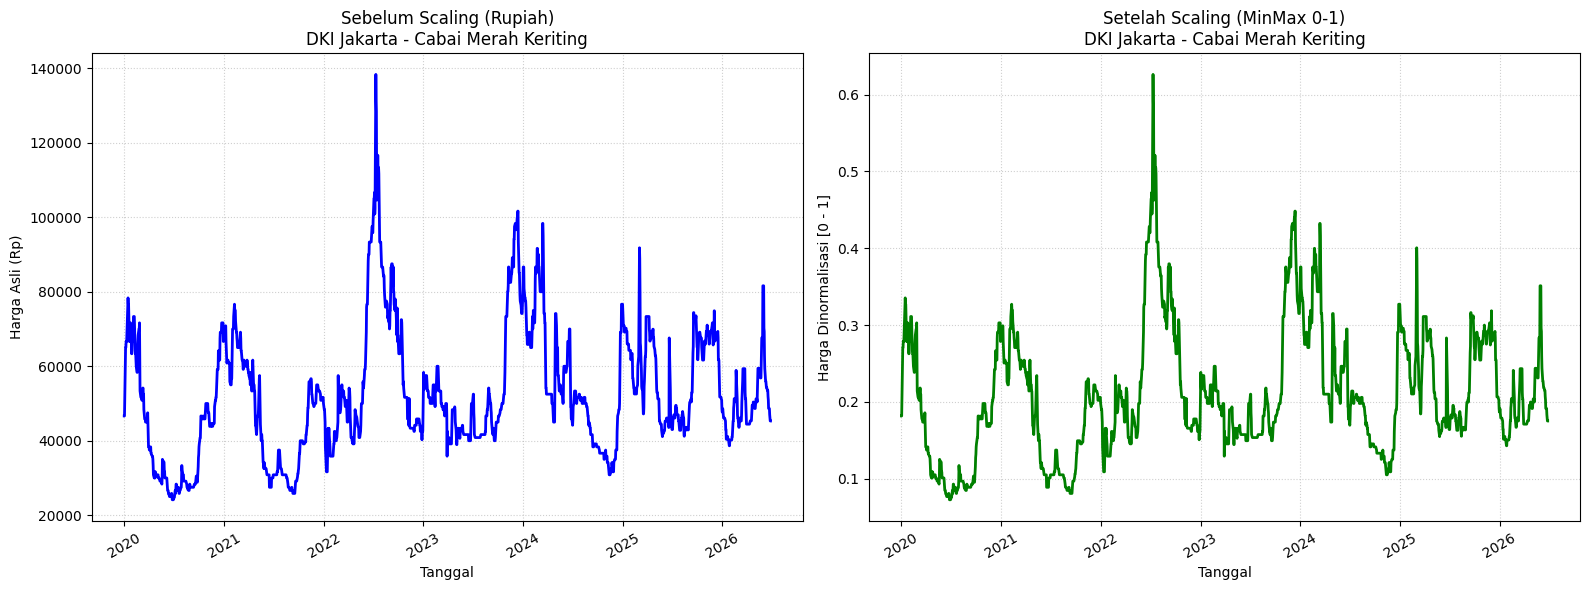

=== PEMBUKTIAN NORMALISASI (MIN-MAX SCALING) ===

[BEFORE] 10 Data Awal Harga Asli (Rupiah):


,tanggal,harga
0,2020-01-01,46650.0
1,2020-01-02,46650.0
2,2020-01-03,51650.0
3,2020-01-06,65000.0
4,2020-01-07,65000.0
5,2020-01-08,66650.0
6,2020-01-09,66650.0
7,2020-01-10,66650.0
8,2020-01-13,73350.0
9,2020-01-14,75000.0



[AFTER] 10 Data Awal Setelah Scaling (Rentang 0-1):


,harga
0,0.181620
1,0.181620
2,0.205868
3,0.270611
4,0.270611
5,0.278613
6,0.278613
7,0.278613
8,0.311106
9,0.319108


In [8]:
provinsi = "DKI Jakarta"
jenis = "Cabai Merah Keriting"

split_dir = "split"
filename = f"{provinsi}_{jenis}.xlsx"
filepath = os.path.join(split_dir, filename)

# Load data dan bersihkan harga
data = pd.read_excel(filepath)
if "date" in data.columns:
    data = data.rename(columns={"date": "tanggal"})
data["tanggal"] = pd.to_datetime(data["tanggal"])
data = data.sort_values("tanggal").reset_index(drop=True)
data["harga"] = data["harga"].apply(bersihkan_harga)
data["harga"] = data["harga"].interpolate(method="linear").bfill().ffill()

# Load Scaler Global
scaler = joblib.load("scalers/global_scaler.save")

prices_raw = data["harga"].values.reshape(-1, 1).astype(float)
prices_scaled = scaler.transform(prices_raw)

# Buat Plot Perbandingan Sebelum vs Sesudah Scaling
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Sebelum Scaling
ax1.plot(data["tanggal"], data["harga"], color="blue", linewidth=2)
ax1.set_title(f"Sebelum Scaling (Rupiah)\n{provinsi} - {jenis}", fontsize=12)
ax1.set_xlabel("Tanggal")
ax1.set_ylabel("Harga Asli (Rp)")
ax1.grid(True, linestyle=":", alpha=0.6)
ax1.tick_params(axis='x', rotation=30)

# Sesudah Scaling
ax2.plot(data["tanggal"], prices_scaled, color="green", linewidth=2)
ax2.set_title(f"Setelah Scaling (MinMax 0-1)\n{provinsi} - {jenis}", fontsize=12)
ax2.set_xlabel("Tanggal")
ax2.set_ylabel("Harga Dinormalisasi [0 - 1]")
ax2.grid(True, linestyle=":", alpha=0.6)
ax2.tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

print("=== PEMBUKTIAN NORMALISASI (MIN-MAX SCALING) ===")
print("\n[BEFORE] 10 Data Awal Harga Asli (Rupiah):")
display(data[["tanggal", "harga"]].head(15))

print("\n[AFTER] 10 Data Awal Setelah Scaling (Rentang 0-1):")
display(pd.DataFrame(prices_scaled, columns=["harga"]).head(15))

In [9]:
df_scaled = pd.DataFrame(prices_scaled, columns=["harga"])
reframed = series_to_supervised(df_scaled, LAG, 1)

print("=== PEMBUKTIAN TABEL DERET WAKTU MENJADI SUPERVISED LEARNING ===")
print("\n[BEFORE] 10 Data Awal (Deret Waktu 1 Kolom):")
display(df_scaled.head(10))

print("\n[AFTER] 3 Sampel Awal Hasil Reframing Lags (Input Lags vs Target):")
cols_to_show = [f"var1(t-{i})" for i in range(7, 0, -1)] + ["var1(t)"]
display(reframed[cols_to_show].head(3))

=== PEMBUKTIAN TABEL DERET WAKTU MENJADI SUPERVISED LEARNING ===

[BEFORE] 10 Data Awal (Deret Waktu 1 Kolom):


,harga
0,0.181620
1,0.181620
2,0.205868
3,0.270611
4,0.270611
5,0.278613
6,0.278613
7,0.278613
8,0.311106
9,0.319108



[AFTER] 3 Sampel Awal Hasil Reframing Lags (Input Lags vs Target):


,var1(t-7),var1(t-6),var1(t-5),var1(t-4),var1(t-3),var1(t-2),var1(t-1),var1(t)
7,0.181620,0.181620,0.205868,0.270611,0.270611,0.278613,0.278613,0.278613
8,0.181620,0.205868,0.270611,0.270611,0.278613,0.278613,0.278613,0.311106
9,0.205868,0.270611,0.270611,0.278613,0.278613,0.278613,0.311106,0.319108
